# Q1 2025 port-call visibility data-quality review

This notebook asks whether a one-time Q1 2025 port-call event feed is reliable enough for downstream visibility workflows. It reconciles the published source CSV snapshot to its request manifest and profiles `portAreaDetails` before any downstream dataset is built.

Source: Fintraffic / digitraffic.fi, [CC BY 4.0](https://creativecommons.org/licenses/by/4.0/). The repository includes only the selected analytical fields required for this review.


## Scope and guardrails

- Backfill window: `[2025-01-01T00:00:00Z, 2025-04-01T00:00:00Z)`, requested in daily ATA windows.
- One API response may contain several `portAreaDetails`; this notebook uses one row per nested area detail.
- A repeated `portCallId` is retained and investigated. This notebook does not silently deduplicate source records.
- `ATD - ATA` is a timestamp interval for sequence checking only. It is not labelled delay, berth waiting time, cargo handling time, or a business KPI.

In [1]:
from base64 import b64encode
from io import BytesIO
from pathlib import Path
import json

import matplotlib.pyplot as plt
from IPython.display import HTML, display
import pandas as pd

pd.set_option('display.max_columns', 20)
plt.style.use('seaborn-v0_8-whitegrid')

In [2]:
def find_data_dir():
    for folder in (Path.cwd(), *Path.cwd().parents):
        candidate = folder / 'data' / 'q1-2025'
        if (candidate / 'backfill_manifest.csv').exists():
            return candidate
    raise FileNotFoundError('Q1 CSV snapshot not found. Run from the project directory after cloning the repository.')

data_dir = find_data_dir()
manifest_chunks = pd.read_csv(data_dir / 'backfill_manifest.csv')
source_calls = pd.read_csv(data_dir / 'source_responses.csv')
manifest = {
    'backfill_start': manifest_chunks['ata_from'].min(),
    'backfill_end_exclusive': manifest_chunks['ata_to_exclusive'].max(),
    'chunk_count': len(manifest_chunks),
    'source_record_count': int(manifest_chunks['source_response_count'].sum()),
    'distinct_port_call_ids': source_calls['port_call_id'].nunique(),
    'duplicate_port_call_id_count': source_calls['port_call_id'].duplicated().sum(),
    'backfill_status': 'complete_with_source_overlaps',
}

pd.Series({
    'window_start': manifest['backfill_start'],
    'window_end_exclusive': manifest['backfill_end_exclusive'],
    'chunk_count': manifest['chunk_count'],
    'source_record_count': manifest['source_record_count'],
    'distinct_port_call_ids': manifest['distinct_port_call_ids'],
    'source_overlap_count': manifest['duplicate_port_call_id_count'],
    'backfill_status': manifest['backfill_status'],
})


window_start                       2025-01-01T00:00:00Z
window_end_exclusive               2025-04-01T00:00:00Z
chunk_count                                          90
source_record_count                                7135
distinct_port_call_ids                             7134
source_overlap_count                                  1
backfill_status           complete_with_source_overlaps
dtype: object

In [3]:
area_details = pd.read_csv(data_dir / 'port_area_details.csv')
for column in ['ata', 'atd']:
    area_details[column] = pd.to_datetime(area_details[column], utc=True)
area_details['ata_to_atd_hours'] = (area_details['atd'] - area_details['ata']).dt.total_seconds() / 3600

print(f'Loaded {len(source_calls):,} source response records and {len(area_details):,} nested area-detail records.')


Loaded 7,135 source response records and 7,176 nested area-detail records.


## 1. Source-to-manifest reconciliation

The published request manifest and source-response CSV establish a fixed, inspectable Q1 boundary. The first check confirms that the source-level total agrees with the manifest.


In [4]:
reconciliation = pd.DataFrame([
    ('Source response records', manifest['source_record_count'], len(source_calls)),
    ('Daily chunks', manifest['chunk_count'], source_calls['source_chunk'].nunique()),
    ('Distinct port-call IDs', manifest['distinct_port_call_ids'], source_calls['port_call_id'].nunique()),
], columns=['metric', 'manifest', 'loaded'])
reconciliation['matches'] = reconciliation['manifest'].eq(reconciliation['loaded'])
reconciliation

if not reconciliation['matches'].all():
    raise ValueError('Raw snapshots do not reconcile with the manifest.')

In [5]:
source_overlaps = (
    source_calls.groupby('port_call_id', as_index=False)
    .agg(source_record_count=('source_chunk', 'size'), source_chunks=('source_chunk', lambda values: ', '.join(sorted(values))))
    .query('source_record_count > 1')
)
source_overlaps

,port_call_id,source_record_count,source_chunks
6088,3223844,2,port_calls__20250205T000000Z__20250206T000000Z...


The repeated source ID is expected from the ingestion finding: one response has nested area details whose actual-arrival timestamps fall on separate days. It remains in the raw layer until the transformation contract defines a canonical record rule.

## 2. Nested area-detail quality profile

The following checks operate at the nested `portAreaDetails` grain. Missing actual timestamps and negative intervals are quality exceptions, not values to impute.

In [6]:
quality_summary = pd.DataFrame({
    'records': [len(area_details)],
    'missing_ata': [area_details['ata'].isna().sum()],
    'missing_atd': [area_details['atd'].isna().sum()],
    'negative_ata_to_atd': [(area_details['ata_to_atd_hours'] < 0).sum()],
    'exact_duplicate_candidate_keys': [area_details.duplicated(['port_call_id', 'port_area_code', 'berth_code', 'ata', 'atd']).sum()],
})
quality_summary

,records,missing_ata,missing_atd,negative_ata_to_atd,exact_duplicate_candidate_keys
0,7176,33,79,0,4



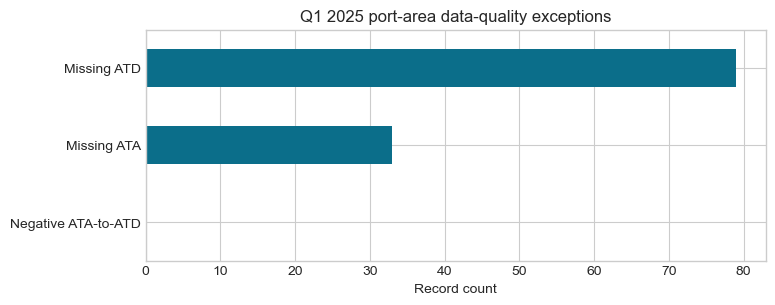

In [7]:
missing_by_field = pd.Series({
    'Missing ATA': area_details['ata'].isna().sum(),
    'Missing ATD': area_details['atd'].isna().sum(),
    'Negative ATA-to-ATD': (area_details['ata_to_atd_hours'] < 0).sum(),
})

ax = missing_by_field.sort_values().plot.barh(figsize=(8, 3), color='#0b6e8a')
ax.set_title('Q1 2025 port-area data-quality exceptions')
ax.set_xlabel('Record count')
ax.set_ylabel('')
figure = ax.get_figure()
buffer = BytesIO()
figure.savefig(buffer, format='png', bbox_inches='tight')
plt.close(figure)
image_data = b64encode(buffer.getvalue()).decode()
display(HTML(f'<img alt="Horizontal bar chart of Q1 2025 missing ATA, missing ATD, and negative interval counts." src="data:image/png;base64,{image_data}">'))

In [8]:
coverage_by_port = (
    area_details.assign(has_ata=area_details['ata'].notna(), has_atd=area_details['atd'].notna())
    .groupby('port_code', as_index=False)
    .agg(area_detail_records=('port_call_id', 'size'), ata_coverage=('has_ata', 'mean'), atd_coverage=('has_atd', 'mean'))
    .sort_values('area_detail_records', ascending=False)
)
coverage_by_port.head(10)

,port_code,area_detail_records,ata_coverage,atd_coverage
6,FIHEL,1753,0.998289,0.996577
25,FIMHQ,698,1.000000,0.998567
22,FILAN,616,1.000000,1.000000
20,FIKTK,560,0.996429,0.987500
7,FIHKO,336,1.000000,0.985119
39,FITKU,323,0.990712,0.984520
26,FINLI,316,1.000000,0.990506
35,FISKV,264,1.000000,0.992424
2,FIECK,261,1.000000,1.000000
34,FIRAU,239,1.000000,0.987448


## 3. What this establishes

- The published Q1 source CSV snapshot reconciles to the request manifest, so later transformations have a traceable source boundary.
- The raw API structure is one port-call response to zero or more area-detail records. The analytics mart makes this grain explicit.
- The source overlap and timestamp gaps are visible before aggregation. The next notebook defines canonicalisation, exclusion reasons, and completed-event coverage.
